<div align="center">

###
### ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ ОБРАЗОВАТЕЛЬНОЕ  
### БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ  
### «ФИНАНСОВЫЙ УНИВЕРСИТЕТ ПРИ ПРАВИТЕЛЬСТВЕ  
### РОССИЙСКОЙ ФЕДЕРАЦИИ»  
### (ФИНАНСОВЫЙ УНИВЕРСИТЕТ)  

</div align="center">

---

<div align="center">

### Кафедра искусственного интеллекта  
### Факультета информационных технологий и анализа больших данных  

</div>

---

<div align="center">

## Курсовая работа
### по дисциплине «Машинное обучение»  
#### на тему:  
### «Прогнозирование оттока клиентов банка на основе их транзакционной активности и профиля»  

</div>

---

<div align="right">

Выполнил:  
студент группы ПМ23-6  
Факультета информационных  
технологий и анализа больших данных  
Романов Г.М.

Научный руководитель:  
Казанцев А.М.

</div>

---

<div align="center">

    Москва 2026
</div>

## 1. Постановка задачи

**Объект исследования:** клиенты банка и их поведенческие/финансовые характеристики.

**Предмет исследования:** методы машинного обучения и сетевого анализа для прогнозирования вероятности ухода клиента из банка.

**Цель работы:** построить и сравнить модели прогнозирования оттока клиентов банка, дополнив классические табличные признаки сетевыми признаками, полученными из графа похожести клиентов.

**Задачи исследования:**

1. Загрузить и описать набор данных о клиентах банка.
2. Провести предварительный анализ данных: размерность, пропуски, распределение целевой переменной, смысл признаков.
3. Выполнить очистку и преобразование данных.
4. Сформировать граф похожести клиентов, где вершины — клиенты, а ребра соединяют клиентов с похожими признаками.
5. Рассчитать сетевые характеристики вершин и добавить их как признаки модели.
6. Разделить данные на обучающую, валидационную и тестовую выборки.
7. Обучить несколько классических ML-моделей.
8. Реализовать и обучить минимум 3 архитектуры нейросетей на PyTorch.
9. Выполнить автоматический подбор гиперпараметров.
10. Сравнить модели по ROC-AUC, PR-AUC, Accuracy, Precision, Recall и F1-score.
11. Сделать выводы о качестве моделей и влиянии сетевых признаков.

**Тип задачи:** бинарная классификация.  
**Целевая переменная:** `churn`, где `1` означает уход клиента, а `0` — сохранение клиента.

In [ ]:
import os
import math
import time
import random
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx
import scipy.sparse as sp

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import kneighbors_graph

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Версия pandas:", pd.__version__)
print("Версия NetworkX:", nx.__version__)
print("Версия PyTorch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())

Версия pandas: 2.2.2
Версия NetworkX: 3.6.1
Версия PyTorch: 2.10.0+cpu
CUDA доступна: False


## 2. Загрузка данных

Ожидается файл `churn_prediction.csv` в той же папке, где открыт ноутбук.

Если ноутбук запускается в Google Colab, нужно загрузить файл `churn_prediction.csv` в `/content/` или изменить переменную `DATA_FILENAME`.

In [ ]:
DATA_FILENAME = "churn_prediction.csv"

def find_data_file(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/content") / filename,
        Path("/mnt/data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Файл {filename!r} не найден. Поместите CSV рядом с ноутбуком "
        f"или измените переменную DATA_FILENAME. Проверенные пути: {candidates}"
    )

DATA_PATH = find_data_file(DATA_FILENAME)
df_raw = pd.read_csv(DATA_PATH)

print("Файл загружен:", DATA_PATH)
print("Размер датасета:", df_raw.shape)
display(df_raw.head())

Файл загружен: churn_prediction.csv
Размер датасета: (28382, 21)


,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


## 3. Первичный анализ данных

На этом этапе проверяем:

- сколько строк и столбцов в датасете;
- какие типы данных используются;
- есть ли пропуски;
- как распределена целевая переменная `churn`;
- какие признаки потенциально важны для прогнозирования оттока.

In [ ]:
print("Информация о датасете:")
display(df_raw.info())

missing_report = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_share=lambda x: x["missing_count"] / len(df_raw))
    .sort_values("missing_count", ascending=False)
)

print("Пропуски по признакам:")
display(missing_report)

if "churn" not in df_raw.columns:
    raise ValueError("В датасете не найден столбец churn. Проверьте название целевой переменной.")

print("Распределение целевой переменной churn:")
display(df_raw["churn"].value_counts(dropna=False).to_frame("count"))
display(df_raw["churn"].value_counts(normalize=True, dropna=False).to_frame("share"))

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_m

None

Пропуски по признакам:


,missing_count,missing_share
dependents,2463,0.086780
city,803,0.028293
gender,525,0.018498
occupation,80,0.002819
customer_id,0,0.000000
vintage,0,0.000000
age,0,0.000000
customer_nw_category,0,0.000000
branch_code,0,0.000000
current_balance,0,0.000000


Распределение целевой переменной churn:


,count
churn,
0,23122
1,5260


,share
churn,
0,0.814671
1,0.185329


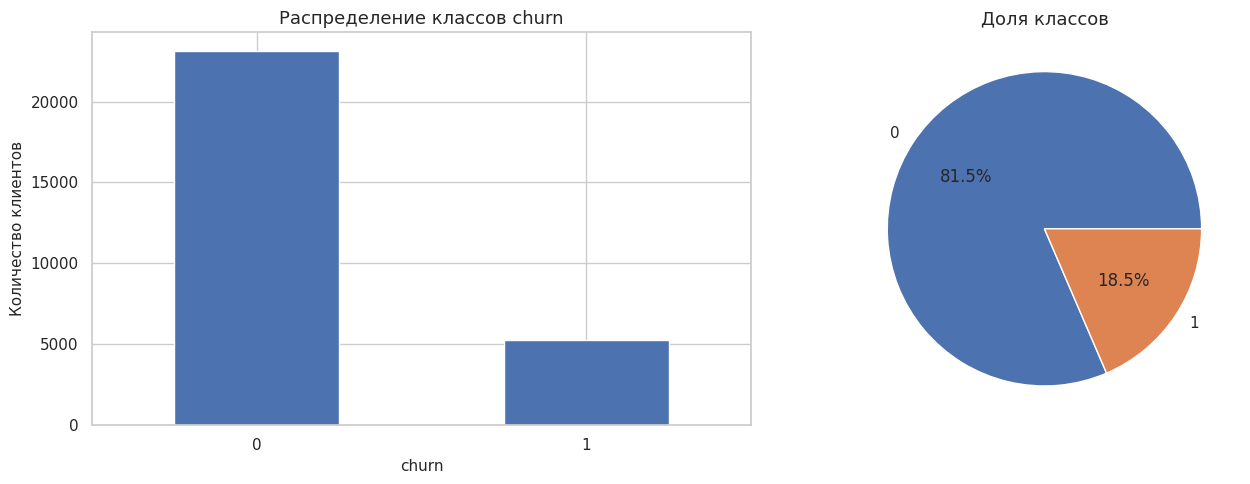

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw["churn"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение классов churn")
axes[0].set_xlabel("churn")
axes[0].set_ylabel("Количество клиентов")
axes[0].tick_params(axis="x", rotation=0)

class_share = df_raw["churn"].value_counts(normalize=True).sort_index()
axes[1].pie(class_share.values, labels=class_share.index.astype(str), autopct="%1.1f%%")
axes[1].set_title("Доля классов")

plt.tight_layout()
plt.show()

### Описание признаков

Ниже приведено смысловое описание основных признаков. Если в датасете есть дополнительные столбцы, они также будут обработаны автоматически.

In [ ]:
feature_description = {
    "customer_id": "идентификатор клиента; не должен использоваться как числовой предиктор",
    "vintage": "срок обслуживания клиента в банке",
    "age": "возраст клиента",
    "gender": "пол клиента",
    "dependents": "количество иждивенцев",
    "occupation": "тип занятости клиента",
    "city": "город/код города клиента",
    "customer_nw_category": "категория клиента по уровню капитала/состояния",
    "branch_code": "код отделения банка",
    "current_balance": "текущий баланс",
    "previous_month_end_balance": "баланс на конец предыдущего месяца",
    "average_monthly_balance_prevQ": "средний месячный баланс за предыдущий квартал",
    "average_monthly_balance_prevQ2": "средний месячный баланс за квартал до предыдущего",
    "current_month_credit": "зачисления за текущий месяц",
    "previous_month_credit": "зачисления за предыдущий месяц",
    "current_month_debit": "списания за текущий месяц",
    "previous_month_debit": "списания за предыдущий месяц",
    "current_month_balance": "средний/текущий месячный баланс",
    "previous_month_balance": "баланс за предыдущий месяц",
    "last_transaction": "дата последней транзакции",
    "churn": "целевая переменная: факт оттока клиента",
}

description_df = pd.DataFrame(
    [(col, feature_description.get(col, "дополнительный признак из исходного датасета"), str(df_raw[col].dtype))
     for col in df_raw.columns],
    columns=["Признак", "Физический смысл", "Тип данных"]
)

display(description_df)

,Признак,Физический смысл,Тип данных
0,customer_id,идентификатор клиента; не должен использоватьс...,int64
1,vintage,срок обслуживания клиента в банке,int64
2,age,возраст клиента,int64
3,gender,пол клиента,object
4,dependents,количество иждивенцев,float64
5,occupation,тип занятости клиента,object
6,city,город/код города клиента,float64
7,customer_nw_category,категория клиента по уровню капитала/состояния,int64
8,branch_code,код отделения банка,int64
9,current_balance,текущий баланс,float64


## 4. Анализ пропусков и числовых признаков

Пропуски не удаляются без необходимости. Для табличных моделей корректнее использовать импутацию:

- числовые признаки — медианой;
- категориальные признаки — самым частым значением.

Такой подход лучше, чем массовое удаление строк, потому что сохраняет больше данных для обучения.

In [ ]:
# Связь пропусков с целевой переменной: если признак содержит пропуски, проверим средний churn для пропусков/непропусков.
missing_effect_rows = []
for col in df_raw.columns:
    if col == "churn":
        continue
    if df_raw[col].isna().any():
        tmp = df_raw.groupby(df_raw[col].isna())["churn"].agg(["count", "mean"])
        for is_missing, row in tmp.iterrows():
            missing_effect_rows.append({
                "feature": col,
                "is_missing": is_missing,
                "count": row["count"],
                "mean_churn": row["mean"],
            })

missing_effect = pd.DataFrame(missing_effect_rows)
if len(missing_effect) > 0:
    display(missing_effect.sort_values(["feature", "is_missing"]))
else:
    print("Пропусков в признаках нет.")

,feature,is_missing,count,mean_churn
6,city,False,27579.0,0.184815
7,city,True,803.0,0.202989
2,dependents,False,25919.0,0.182607
3,dependents,True,2463.0,0.213967
0,gender,False,27857.0,0.185016
1,gender,True,525.0,0.201905
4,occupation,False,28302.0,0.185393
5,occupation,True,80.0,0.162500


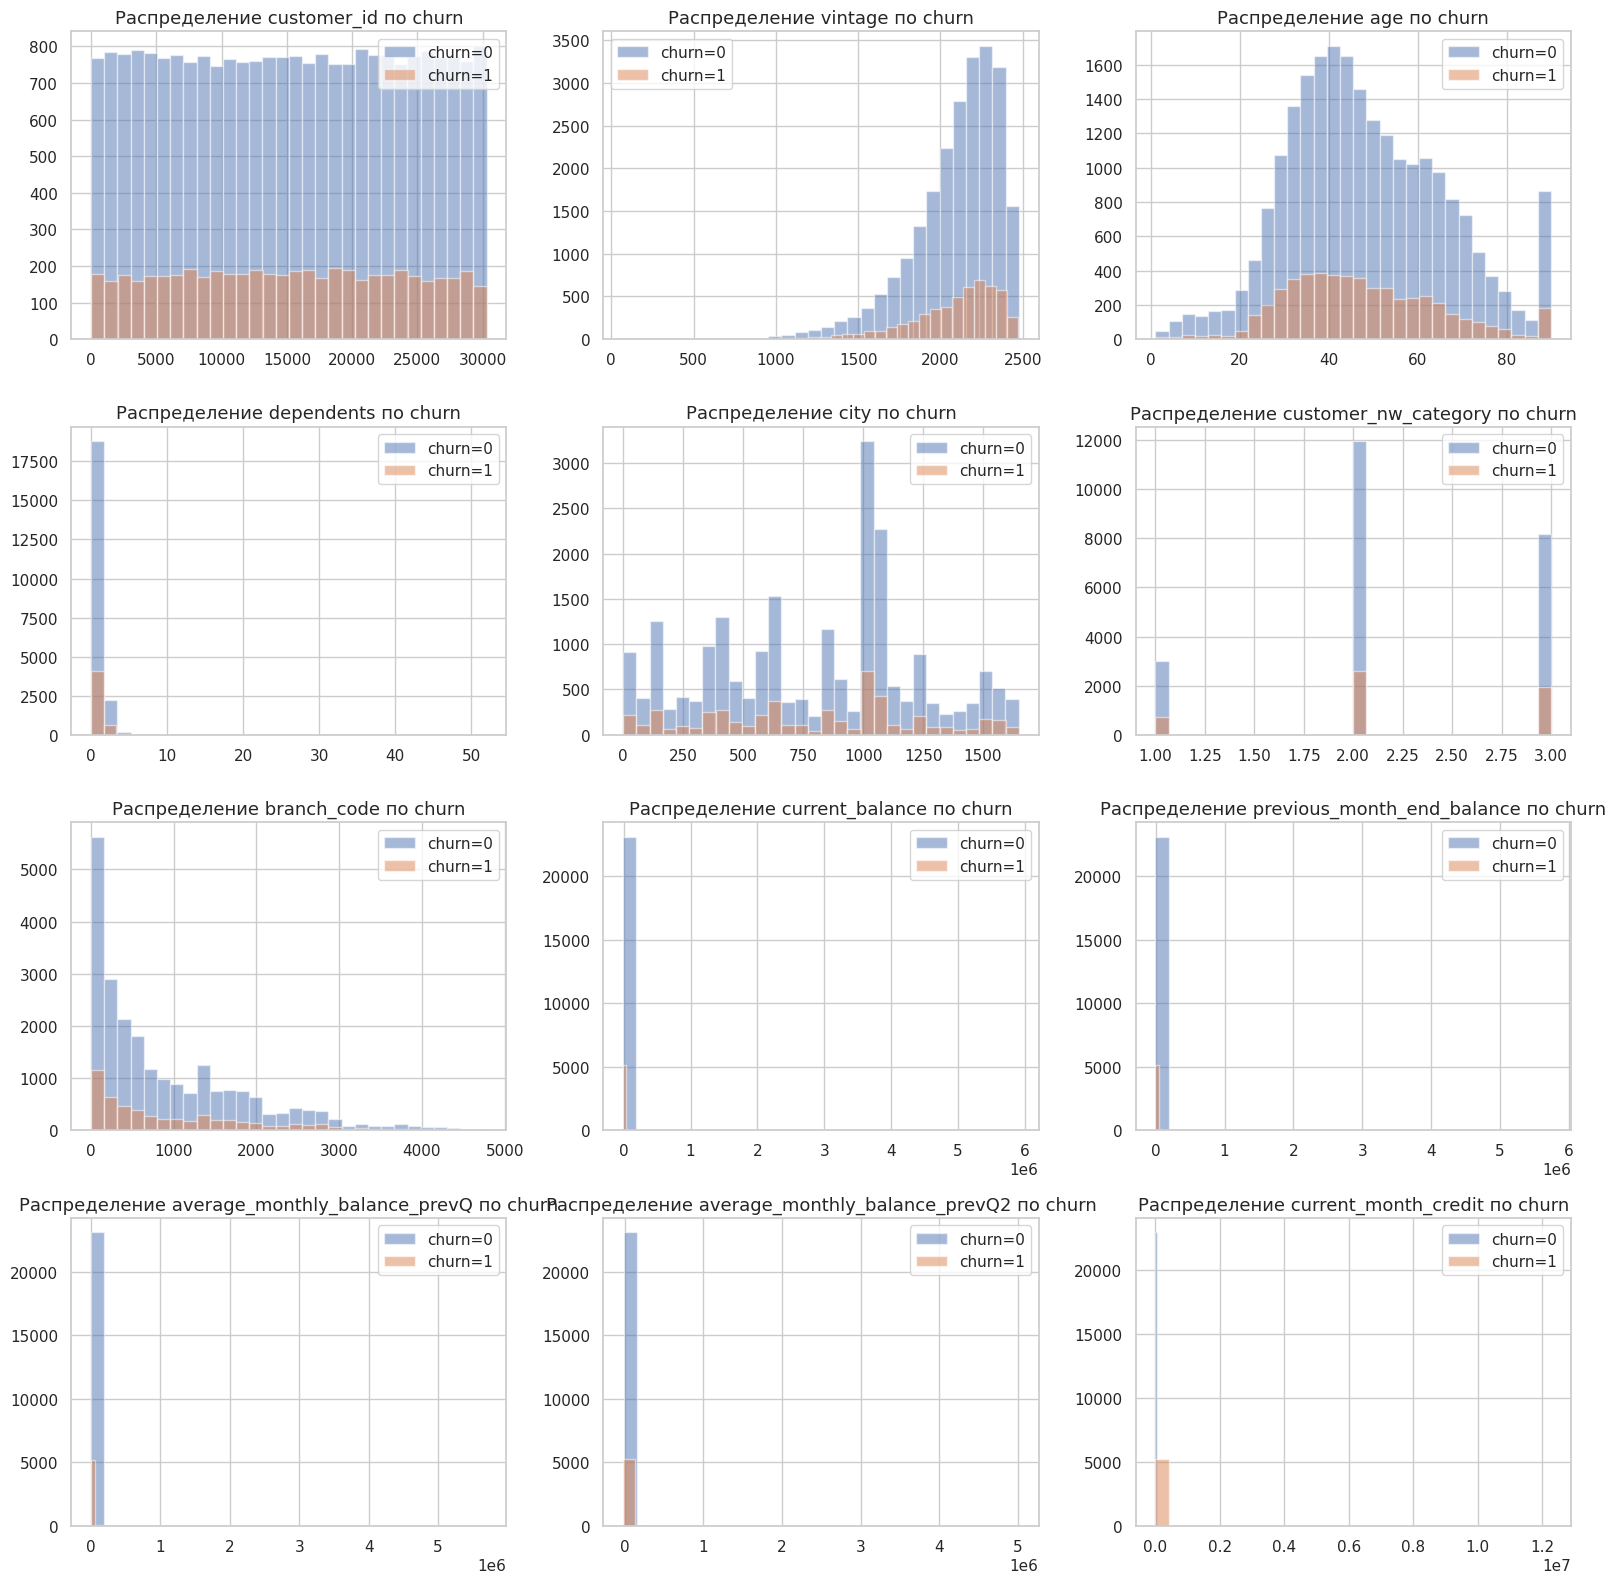

In [ ]:
# Распределения основных числовых признаков
numeric_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.drop("churn", errors="ignore").tolist()

cols_to_plot = numeric_cols_raw[:12]
if cols_to_plot:
    n_cols = 3
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols_to_plot):
        for cls in sorted(df_raw["churn"].dropna().unique()):
            values = df_raw.loc[df_raw["churn"] == cls, col].dropna()
            ax.hist(values, bins=30, alpha=0.5, label=f"churn={cls}")
        ax.legend()
        ax.set_title(f"Распределение {col} по churn")

    for ax in axes[len(cols_to_plot):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Числовые признаки для визуализации не найдены.")

,corr_with_churn
previous_month_debit,0.073058
current_month_debit,0.048041
previous_month_credit,0.042179
branch_code,0.035469
dependents,0.033487
current_balance,-0.024181
current_month_credit,0.020755
age,-0.020012
average_monthly_balance_prevQ2,0.018376
previous_month_balance,0.014593


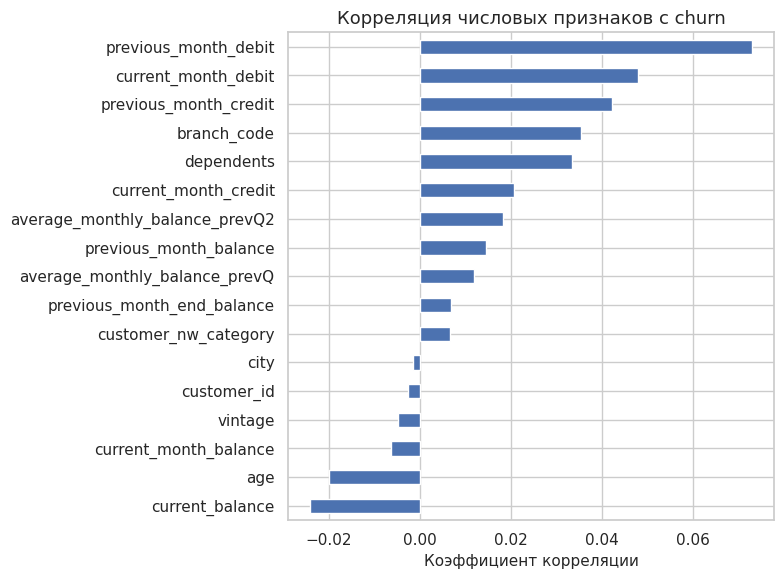

In [ ]:
# Корреляции числовых признаков с целевой переменной
if len(numeric_cols_raw) > 0:
    corr_with_target = (
        df_raw[numeric_cols_raw + ["churn"]]
        .corr(numeric_only=True)["churn"]
        .drop("churn")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    display(corr_with_target.to_frame("corr_with_churn"))

    plt.figure(figsize=(8, max(5, len(corr_with_target) * 0.35)))
    corr_with_target.sort_values().plot(kind="barh")
    plt.title("Корреляция числовых признаков с churn")
    plt.xlabel("Коэффициент корреляции")
    plt.tight_layout()
    plt.show()
else:
    print("Числовые признаки не найдены.")

## 5. Feature Engineering

Добавим признаки, которые логически связаны с оттоком:

- изменение кредитовых операций;
- изменение дебетовых операций;
- изменение баланса;
- давность последней транзакции;
- отношение списаний к зачислениям;
- изменение стабильности баланса;
- флаг падения активности.

Все новые признаки строятся только из исходных признаков клиента и не используют целевую переменную.

In [ ]:
def add_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """Создает дополнительные признаки для задачи прогнозирования оттока."""
    df = df.copy()

    cols = set(df.columns)

    if {"current_month_credit", "previous_month_credit"}.issubset(cols):
        df["credit_diff"] = df["current_month_credit"] - df["previous_month_credit"]
        df["credit_ratio"] = df["current_month_credit"] / (df["previous_month_credit"].abs() + 1)

    if {"current_month_debit", "previous_month_debit"}.issubset(cols):
        df["debit_diff"] = df["current_month_debit"] - df["previous_month_debit"]
        df["debit_ratio"] = df["current_month_debit"] / (df["previous_month_debit"].abs() + 1)

    if {"current_balance", "previous_month_balance"}.issubset(cols):
        df["balance_diff"] = df["current_balance"] - df["previous_month_balance"]
        df["balance_ratio"] = df["current_balance"] / (df["previous_month_balance"].abs() + 1)

    if {"current_month_debit", "current_month_credit"}.issubset(cols):
        df["activity_ratio"] = df["current_month_debit"] / (df["current_month_credit"].abs() + 1)

    if {"average_monthly_balance_prevQ", "average_monthly_balance_prevQ2"}.issubset(cols):
        df["balance_stability"] = df["average_monthly_balance_prevQ"] - df["average_monthly_balance_prevQ2"]
        df["balance_stability_ratio"] = df["average_monthly_balance_prevQ"] / (df["average_monthly_balance_prevQ2"].abs() + 1)

    if {"current_month_credit", "previous_month_credit"}.issubset(cols):
        df["activity_drop"] = (df["current_month_credit"] < df["previous_month_credit"]).astype(int)

    if "last_transaction" in cols:
        last_tx = pd.to_datetime(df["last_transaction"], errors="coerce")
        if last_tx.notna().any():
            df["recency_days"] = (last_tx.max() - last_tx).dt.days
        df = df.drop(columns=["last_transaction"])

    # customer_id — идентификатор, его нельзя использовать как числовой признак.
    df = df.drop(columns=["customer_id"], errors="ignore")

    return df

# Удаляем только строки с отсутствующей целевой переменной.
df = df_raw.dropna(subset=["churn"]).reset_index(drop=True).copy()
df = add_feature_engineering(df)

# Приведение target к 0/1.
if not pd.api.types.is_numeric_dtype(df["churn"]):
    y_raw = df["churn"].astype(str).str.lower().str.strip()
    mapping = {
        "yes": 1, "y": 1, "true": 1, "1": 1, "churn": 1,
        "no": 0, "n": 0, "false": 0, "0": 0, "not churn": 0,
    }
    y = y_raw.map(mapping)
    if y.isna().any():
        le_target = LabelEncoder()
        y = pd.Series(le_target.fit_transform(df["churn"].astype(str)), index=df.index)
        print("Целевая переменная была закодирована LabelEncoder. Классы:", list(le_target.classes_))
else:
    y = df["churn"].astype(int)

X_raw = df.drop(columns=["churn"])

print("Размер после feature engineering:", X_raw.shape)
print("Количество объектов:", len(y))
print("Новые признаки:")
display([col for col in X_raw.columns if col not in df_raw.columns])
display(X_raw.head())

Размер после feature engineering: (28382, 29)
Количество объектов: 28382
Новые признаки:


['credit_diff',
 'credit_ratio',
 'debit_diff',
 'debit_ratio',
 'balance_diff',
 'balance_ratio',
 'activity_ratio',
 'balance_stability',
 'balance_stability_ratio',
 'activity_drop',
 'recency_days']

,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,...,credit_ratio,debit_diff,debit_ratio,balance_diff,balance_ratio,activity_ratio,balance_stability,balance_stability_ratio,activity_drop,recency_days
0,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,...,0.166667,0.00,0.166667,0.00,0.999315,0.166667,9.64,1.005958,0,224.0
1,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,...,0.358974,5385.71,54.019988,-3397.24,0.613336,3516.839744,-4620.15,0.627939,0,60.0
2,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,...,0.378882,5787.50,23.236099,-1156.98,0.771653,3755.732919,2094.23,1.743086,0,NaN
3,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,...,0.319728,-2142.86,0.000219,622.12,1.371752,0.319728,1078.00,2.068940,0,147.0
4,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,...,0.000461,-949.44,0.382454,-749.44,0.552820,442.571429,-227.81,0.877780,1,58.0


## 6. Сетевой анализ: граф похожести клиентов

Чтобы работа соответствовала направлению **сетевого анализа**, построим граф:

- **вершина** — клиент банка;
- **ребро** — связь между похожими клиентами;
- похожесть определяется по признакам клиента после импутации, кодирования категорий и масштабирования;
- для каждого клиента соединяем его с `K_NEIGHBORS` ближайшими соседями.

После построения графа рассчитаем сетевые признаки:

- `graph_degree` — число соседей клиента;
- `graph_degree_centrality` — нормированная степень;
- `graph_pagerank` — PageRank клиента в графе похожести;
- `graph_clustering` — локальная кластеризация;
- `graph_core_number` — номер k-core;
- `graph_component` — номер компоненты связности.

Эти признаки показывают положение клиента среди похожих клиентов и могут быть полезны для прогнозирования оттока.

In [ ]:
def make_onehot_encoder(sparse_output=True):
    """Совместимость с разными версиями scikit-learn."""
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=sparse_output)
    return OneHotEncoder(handle_unknown="ignore", sparse=sparse_output)


def build_similarity_graph_features(
    X_df: pd.DataFrame,
    n_neighbors: int = 10,
    random_state: int = 42,
):
    """Строит kNN-граф похожести клиентов и возвращает сетевые признаки.

    Важно: граф строится только по признакам X, без использования y.
    """
    X_for_graph = X_df.copy()

    # Даты и другие нечисловые признаки обрабатываются как категориальные.
    numeric_cols = X_for_graph.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in X_for_graph.columns if col not in numeric_cols]

    graph_preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(sparse_output=True)),
                ]),
                categorical_cols,
            ),
        ],
        remainder="drop",
        sparse_threshold=1.0,
    )

    X_graph = graph_preprocessor.fit_transform(X_for_graph)

    # На всякий случай ограничим число соседей размером выборки.
    n_neighbors = min(n_neighbors, max(1, X_graph.shape[0] - 1))

    A = kneighbors_graph(
        X_graph,
        n_neighbors=n_neighbors,
        mode="connectivity",
        include_self=False,
        n_jobs=-1,
    )

    # Делаем граф неориентированным: если i похож на j или j похож на i, связь сохраняется.
    A = A.maximum(A.T).tocsr()
    G = nx.from_scipy_sparse_array(A)

    degree = dict(G.degree())
    degree_centrality = nx.degree_centrality(G)
    clustering = nx.clustering(G)
    pagerank = nx.pagerank(G, alpha=0.85, max_iter=100)

    # core_number может быть полезным признаком плотности локальной области графа.
    core_number = nx.core_number(G)

    component_id = {}
    for comp_idx, comp_nodes in enumerate(nx.connected_components(G)):
        for node in comp_nodes:
            component_id[node] = comp_idx

    graph_features = pd.DataFrame({
        "graph_degree": pd.Series(degree),
        "graph_degree_centrality": pd.Series(degree_centrality),
        "graph_pagerank": pd.Series(pagerank),
        "graph_clustering": pd.Series(clustering),
        "graph_core_number": pd.Series(core_number),
        "graph_component": pd.Series(component_id),
    })

    graph_features.index = X_df.index

    graph_summary = {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "components": nx.number_connected_components(G),
        "largest_component_size": max(len(c) for c in nx.connected_components(G)),
        "average_degree": np.mean(list(degree.values())),
        "average_clustering": float(np.mean(list(clustering.values()))),
    }

    return graph_features, G, A, graph_summary

K_NEIGHBORS = 10

graph_features, G_clients, A_clients, graph_summary = build_similarity_graph_features(
    X_raw,
    n_neighbors=K_NEIGHBORS,
    random_state=RANDOM_STATE,
)

print("Сводка по графу похожести клиентов:")
display(pd.Series(graph_summary).to_frame("value"))

print("Первые строки сетевых признаков:")
display(graph_features.head())

Сводка по графу похожести клиентов:


,value
nodes,28382.000000
edges,202403.000000
density,0.000503
components,1.000000
largest_component_size,28382.000000
average_degree,14.262772
average_clustering,0.352817


Первые строки сетевых признаков:


,graph_degree,graph_degree_centrality,graph_pagerank,graph_clustering,graph_core_number,graph_component
0,15,0.000529,0.000038,0.400000,10,0
1,12,0.000423,0.000031,0.363636,10,0
2,12,0.000423,0.000029,0.469697,10,0
3,18,0.000634,0.000046,0.385621,10,0
4,14,0.000493,0.000036,0.153846,10,0


### Интерпретация графа

Если клиент имеет высокую степень или высокий PageRank, значит он находится в плотной области похожих клиентов. Если в такой области много клиентов с оттоком, это может быть важным сигналом для модели.

Локальная кластеризация показывает, насколько соседи клиента похожи между собой. Высокая кластеризация означает, что клиент находится внутри плотной группы похожих клиентов.

In [ ]:
# Добавляем сетевые признаки к исходным признакам.
X_enriched = pd.concat([X_raw.reset_index(drop=True), graph_features.reset_index(drop=True)], axis=1)

print("Размер данных без графовых признаков:", X_raw.shape)
print("Размер данных с графовыми признаками:", X_enriched.shape)
print("Добавленные графовые признаки:")
display(graph_features.columns.tolist())

Размер данных без графовых признаков: (28382, 29)
Размер данных с графовыми признаками: (28382, 35)
Добавленные графовые признаки:


['graph_degree',
 'graph_degree_centrality',
 'graph_pagerank',
 'graph_clustering',
 'graph_core_number',
 'graph_component']

## 7. Визуализация графа похожести клиентов

Полный граф может быть слишком большим для наглядной визуализации, поэтому строим визуализацию на подграфе из случайной выборки клиентов.

Цвет вершины показывает класс `churn`, размер вершины — степень в графе похожести.

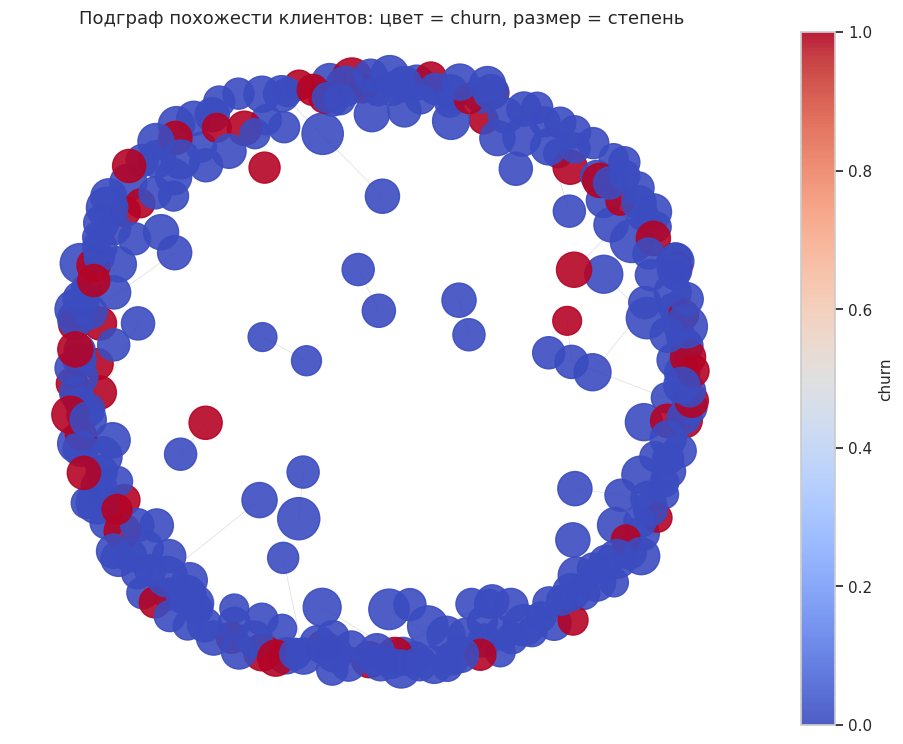

In [ ]:
def stratified_node_sample(y: pd.Series, n: int = 300, random_state: int = 42) -> list:
    """Берет стратифицированную выборку индексов для визуализации."""
    n = min(n, len(y))
    parts = []
    for cls, idx in y.groupby(y).groups.items():
        cls_idx = np.array(list(idx))
        take = max(1, int(n * len(cls_idx) / len(y)))
        take = min(take, len(cls_idx))
        rng = np.random.default_rng(random_state + int(cls))
        parts.extend(rng.choice(cls_idx, size=take, replace=False).tolist())
    return parts[:n]

sample_nodes = stratified_node_sample(y, n=300, random_state=RANDOM_STATE)
G_sample = G_clients.subgraph(sample_nodes).copy()

pos = nx.spring_layout(G_sample, seed=RANDOM_STATE, k=0.35)
node_colors = [int(y.iloc[node]) for node in G_sample.nodes()]
node_sizes = [80 + 35 * graph_features.loc[node, "graph_degree"] for node in G_sample.nodes()]

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G_sample, pos, alpha=0.15, width=0.5)
nodes = nx.draw_networkx_nodes(
    G_sample,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap="coolwarm",
    alpha=0.9,
)
plt.colorbar(nodes, label="churn")
plt.title("Подграф похожести клиентов: цвет = churn, размер = степень")
plt.axis("off")
plt.show()

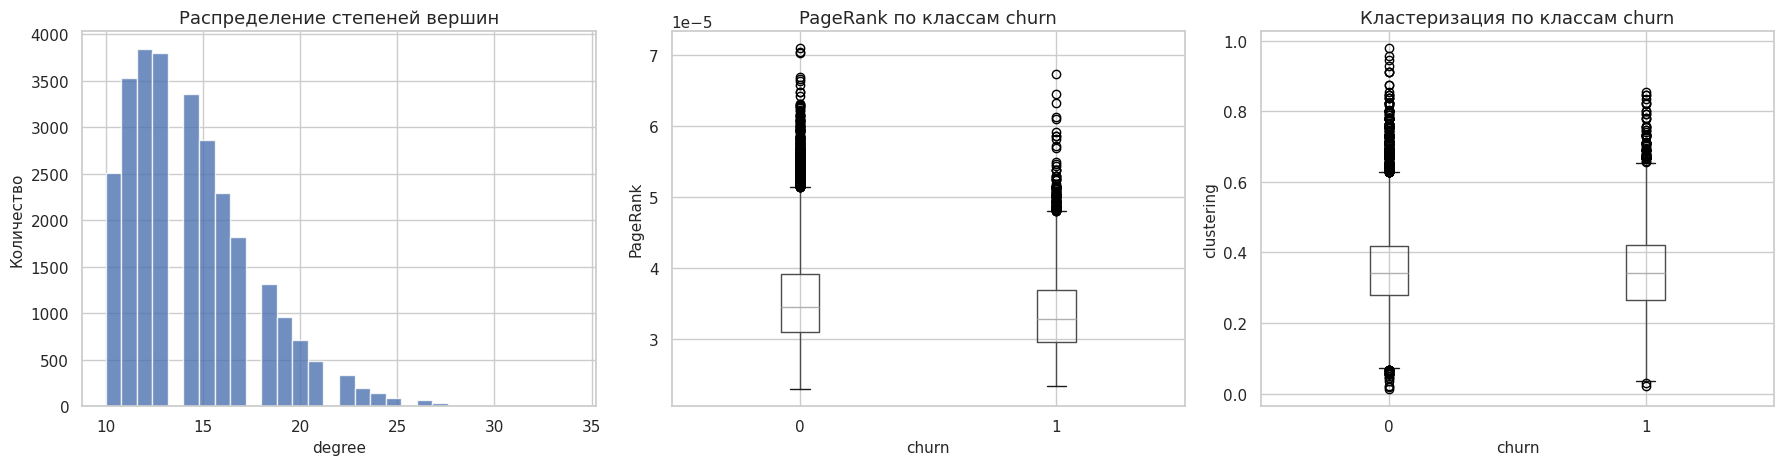

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(graph_features["graph_degree"].dropna(), bins=30, alpha=0.8)
axes[0].set_title("Распределение степеней вершин")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("Количество")

pd.DataFrame({"churn": y, "pagerank": graph_features["graph_pagerank"]}).boxplot(
    column="pagerank", by="churn", ax=axes[1]
)
axes[1].set_title("PageRank по классам churn")
axes[1].set_xlabel("churn")
axes[1].set_ylabel("PageRank")

pd.DataFrame({"churn": y, "clustering": graph_features["graph_clustering"]}).boxplot(
    column="clustering", by="churn", ax=axes[2]
)
axes[2].set_title("Кластеризация по классам churn")
axes[2].set_xlabel("churn")
axes[2].set_ylabel("clustering")

plt.suptitle("")
plt.tight_layout()
plt.show()

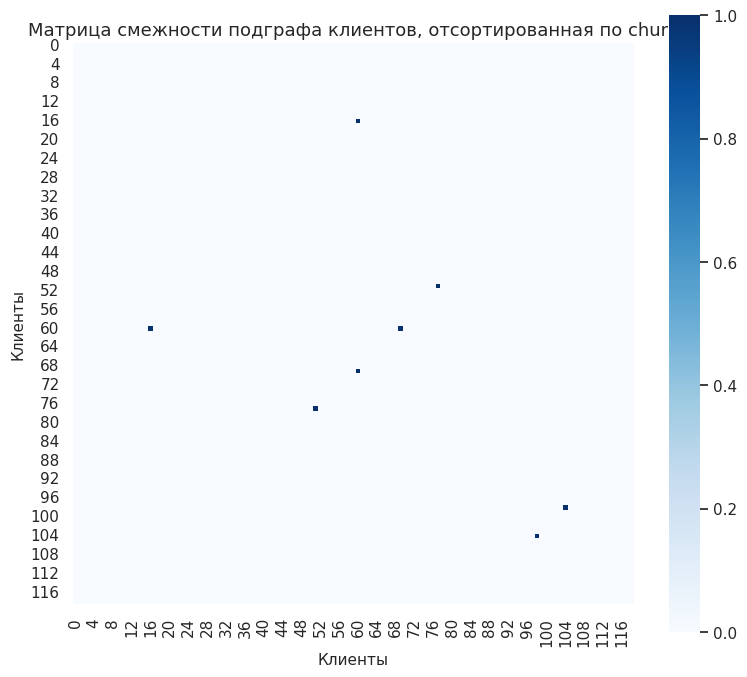

In [ ]:
# Матрица смежности небольшого подграфа, отсортированная по churn.
adj_sample_size = min(120, len(y))
adj_nodes = stratified_node_sample(y, n=adj_sample_size, random_state=RANDOM_STATE)
adj_nodes_sorted = sorted(adj_nodes, key=lambda node: (int(y.iloc[node]), node))

A_sample = nx.to_numpy_array(G_clients.subgraph(adj_nodes_sorted), nodelist=adj_nodes_sorted)

plt.figure(figsize=(8, 7))
sns.heatmap(A_sample, cmap="Blues", cbar=True, square=True)
plt.title("Матрица смежности подграфа клиентов, отсортированная по churn")
plt.xlabel("Клиенты")
plt.ylabel("Клиенты")
plt.tight_layout()
plt.show()

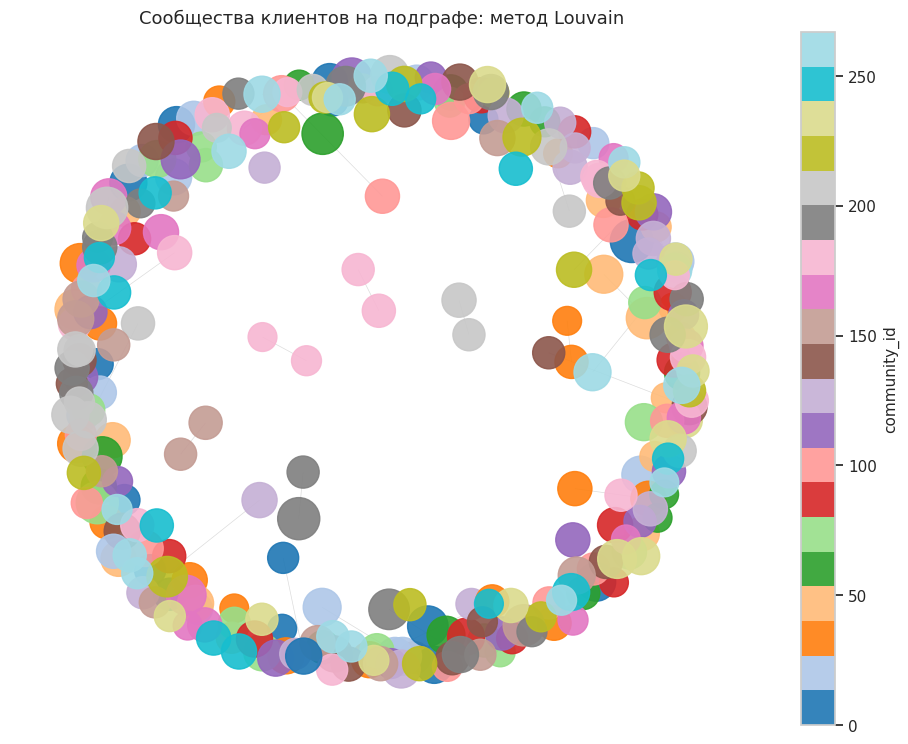

Количество найденных сообществ на подграфе: 268


In [ ]:
# Выделение сообществ на подграфе для визуальной проверки структуры.
try:
    communities = nx.community.louvain_communities(G_sample, seed=RANDOM_STATE)
    community_method = "Louvain"
except Exception:
    communities = list(nx.community.greedy_modularity_communities(G_sample))
    community_method = "Greedy modularity"

community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

community_colors = [community_map[node] for node in G_sample.nodes()]

plt.figure(figsize=(12, 9))
nx.draw_networkx_edges(G_sample, pos, alpha=0.15, width=0.5)
nodes = nx.draw_networkx_nodes(
    G_sample,
    pos,
    node_color=community_colors,
    node_size=node_sizes,
    cmap="tab20",
    alpha=0.9,
)
plt.colorbar(nodes, label="community_id")
plt.title(f"Сообщества клиентов на подграфе: метод {community_method}")
plt.axis("off")
plt.show()

print("Количество найденных сообществ на подграфе:", len(communities))

## 8. Разделение на train / validation / test

Используем стратифицированное разбиение, чтобы доля клиентов с оттоком была примерно одинаковой во всех частях данных.

- `train` — обучение моделей;
- `validation` — выбор архитектуры, порога классификации и гиперпараметров;
- `test` — финальная независимая оценка качества.

In [ ]:
# Сохраняем индексы, чтобы можно было делать одинаковые разбиения для разных наборов признаков.
all_indices = np.arange(len(X_enriched))

idx_train_val, idx_test, y_train_val, y_test = train_test_split(
    all_indices,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

idx_train, idx_val, y_train, y_val = train_test_split(
    idx_train_val,
    y_train_val,
    test_size=0.25,  # 0.25 от 80% = 20% всей выборки
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

X_train_df = X_enriched.iloc[idx_train].copy()
X_val_df = X_enriched.iloc[idx_val].copy()
X_test_df = X_enriched.iloc[idx_test].copy()

print("Train:", X_train_df.shape, "доля churn:", y_train.mean())
print("Validation:", X_val_df.shape, "доля churn:", y_val.mean())
print("Test:", X_test_df.shape, "доля churn:", y_test.mean())

Train: (17028, 35) доля churn: 0.18534178999295278
Validation: (5677, 35) доля churn: 0.18530914215254535
Test: (5677, 35) доля churn: 0.18530914215254535


## 9. Предобработка признаков для моделей

Предобработчик обучается **только на train**, затем применяется к validation и test. Это предотвращает утечку информации из тестовой выборки.

- числовые признаки: медианная импутация + стандартизация;
- категориальные признаки: импутация модой + one-hot encoding.

In [ ]:
def build_tabular_preprocessor(X_train: pd.DataFrame) -> ColumnTransformer:
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_onehot_encoder(sparse_output=False)),
                ]),
                categorical_cols,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

preprocessor = build_tabular_preprocessor(X_train_df)

X_train_np = preprocessor.fit_transform(X_train_df)
X_val_np = preprocessor.transform(X_val_df)
X_test_np = preprocessor.transform(X_test_df)

# На случай, если какая-то версия sklearn вернула sparse matrix.
if sp.issparse(X_train_np):
    X_train_np = X_train_np.toarray()
    X_val_np = X_val_np.toarray()
    X_test_np = X_test_np.toarray()

X_train_np = X_train_np.astype(np.float32)
X_val_np = X_val_np.astype(np.float32)
X_test_np = X_test_np.astype(np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

print("Размер матрицы train после кодирования:", X_train_np.shape)
print("Размер матрицы validation после кодирования:", X_val_np.shape)
print("Размер матрицы test после кодирования:", X_test_np.shape)

Размер матрицы train после кодирования: (17028, 40)
Размер матрицы validation после кодирования: (5677, 40)
Размер матрицы test после кодирования: (5677, 40)


## 10. Метрики качества

Для задачи оттока важно смотреть не только Accuracy, потому что классы часто несбалансированы.

Используем:

- **ROC-AUC** — качество ранжирования клиентов по вероятности оттока;
- **PR-AUC** — особенно полезна при дисбалансе классов;
- **Precision** — доля действительно ушедших клиентов среди тех, кого модель отметила как уходящих;
- **Recall** — какую долю ушедших клиентов модель смогла найти;
- **F1-score** — баланс Precision и Recall;
- **Confusion Matrix** — матрица ошибок.

In [ ]:
def evaluate_binary_classifier(y_true, proba, threshold=0.5) -> dict:
    """Считает основные метрики бинарной классификации."""
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba)
    pred = (proba >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }
    return metrics


def find_best_threshold(y_true, proba, metric="f1"):
    """Подбор порога по validation-выборке."""
    thresholds = np.linspace(0.05, 0.95, 91)
    best_threshold = 0.5
    best_value = -np.inf

    for threshold in thresholds:
        m = evaluate_binary_classifier(y_true, proba, threshold=threshold)
        value = m[metric]
        if value > best_value:
            best_value = value
            best_threshold = threshold

    return best_threshold, best_value


def print_classification_summary(name, y_true, proba, threshold=0.5):
    pred = (np.asarray(proba) >= threshold).astype(int)
    print(f"\n{name}")
    print("Порог:", threshold)
    print(classification_report(y_true, pred, digits=4))
    return confusion_matrix(y_true, pred)

## 11. Базовые классические модели

Сначала обучим классические модели, чтобы получить ориентир качества:

1. Logistic Regression;
2. Random Forest;
3. Gradient Boosting.

Эти модели нужны как baseline для сравнения с нейросетевыми моделями.

In [ ]:
classic_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}

classic_results = []
classic_val_proba = {}
classic_test_proba = {}

for name, model in classic_models.items():
    start = time.time()
    model.fit(X_train_np, y_train_np)
    fit_time = time.time() - start

    val_proba = model.predict_proba(X_val_np)[:, 1]
    test_proba = model.predict_proba(X_test_np)[:, 1]
    threshold, best_val_f1 = find_best_threshold(y_val_np, val_proba, metric="f1")

    val_metrics = evaluate_binary_classifier(y_val_np, val_proba, threshold=threshold)
    test_metrics = evaluate_binary_classifier(y_test_np, test_proba, threshold=threshold)

    classic_val_proba[name] = val_proba
    classic_test_proba[name] = test_proba

    classic_results.append({
        "model": name,
        "type": "classic_ml",
        "fit_time_sec": fit_time,
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "threshold": threshold,
    })

classic_results_df = pd.DataFrame(classic_results).sort_values("test_roc_auc", ascending=False)
display(classic_results_df)

,model,type,fit_time_sec,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,threshold
1,Random Forest,classic_ml,34.603529,0.607917,0.838426,0.855205,0.613636,0.590304,0.601744,0.854337,0.632628,0.31
2,Gradient Boosting,classic_ml,26.486353,0.614804,0.843667,0.858552,0.621939,0.603612,0.612639,0.852831,0.644948,0.31
0,Logistic Regression,classic_ml,0.537682,0.467794,0.731963,0.785802,0.440751,0.579848,0.500821,0.760177,0.466342,0.53


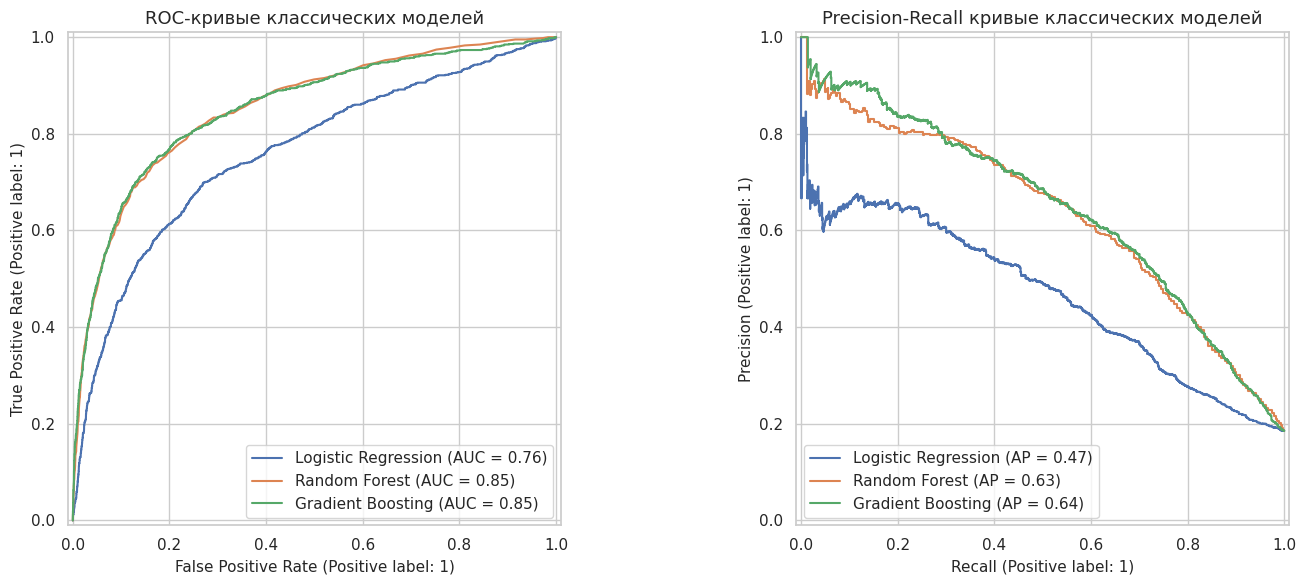

In [ ]:
# ROC и PR-кривые для классических моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, proba in classic_test_proba.items():
    RocCurveDisplay.from_predictions(y_test_np, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test_np, proba, name=name, ax=axes[1])

axes[0].set_title("ROC-кривые классических моделей")
axes[1].set_title("Precision-Recall кривые классических моделей")
plt.tight_layout()
plt.show()

## 12. Нейросетевые модели на PyTorch

Для бинарной классификации используем MLP. Выход модели — один логит, который затем преобразуется в вероятность через sigmoid.

Функция ошибки: `BCEWithLogitsLoss`. Она удобнее, чем отдельные `Sigmoid + BCELoss`, потому что численно устойчивее.

Также учитываем дисбаланс классов через `pos_weight`.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство для обучения:", device)

class MLPBinaryClassifier(nn.Module):
    """Гибкая MLP-модель для бинарной классификации."""
    def __init__(self, input_dim, hidden_layers=(128, 64), dropout=0.2, use_batchnorm=True):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_loader(X, y, batch_size=256, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def predict_torch(model, X, batch_size=4096):
    model.eval()
    proba_parts = []
    loader = make_loader(X, np.zeros(len(X)), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            proba = torch.sigmoid(logits).detach().cpu().numpy()
            proba_parts.append(proba)
    return np.concatenate(proba_parts)


def train_torch_model(
    config,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    patience=8,
    verbose=False,
):
    """Обучает PyTorch-модель и возвращает лучшую модель по validation ROC-AUC."""
    input_dim = X_train.shape[1]
    batch_size = config.get("batch_size", 256)
    lr = config.get("lr", 1e-3)
    weight_decay = config.get("weight_decay", 1e-4)

    model = MLPBinaryClassifier(
        input_dim=input_dim,
        hidden_layers=config.get("hidden_layers", (128, 64)),
        dropout=config.get("dropout", 0.2),
        use_batchnorm=config.get("use_batchnorm", True),
    ).to(device)

    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True)

    n_pos = float(np.sum(y_train == 1))
    n_neg = float(np.sum(y_train == 0))
    pos_weight_value = n_neg / max(n_pos, 1.0)
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_auc = -np.inf
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        train_loss = float(np.mean(epoch_losses))
        val_proba = predict_torch(model, X_val)
        val_auc = roc_auc_score(y_val, val_proba)
        val_pr_auc = average_precision_score(y_val, val_proba)
        val_threshold, val_f1_best = find_best_threshold(y_val, val_proba, metric="f1")

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_pr_auc,
            "val_best_f1": val_f1_best,
            "val_best_threshold": val_threshold,
        }
        history.append(row)

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(
                f"Epoch {epoch:03d} | loss={train_loss:.4f} | "
                f"val_auc={val_auc:.4f} | val_f1={val_f1_best:.4f}"
            )

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history), best_epoch

Устройство для обучения: cpu


## 13. Обучение трех архитектур MLP

Сравним три принципиально разные архитектуры:

1. **Small MLP** — простая модель с одним скрытым слоем;
2. **Medium MLP** — модель с двумя скрытыми слоями;
3. **Deep MLP** — более глубокая модель с регуляризацией.

Это выполняет требование сравнения нескольких альтернативных архитектур.

In [ ]:
architectures = {
    "Small MLP": {
        "hidden_layers": (64,),
        "dropout": 0.10,
        "use_batchnorm": False,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
    "Medium MLP": {
        "hidden_layers": (128, 64),
        "dropout": 0.20,
        "use_batchnorm": True,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 256,
    },
    "Deep MLP": {
        "hidden_layers": (256, 128, 64),
        "dropout": 0.30,
        "use_batchnorm": True,
        "lr": 7e-4,
        "weight_decay": 3e-4,
        "batch_size": 256,
    },
}

torch_models = {}
torch_histories = {}
torch_results = []

torch.manual_seed(RANDOM_STATE)

for name, config in architectures.items():
    print(f"\nОбучение архитектуры: {name}")
    start = time.time()
    model, history, best_epoch = train_torch_model(
        config,
        X_train_np,
        y_train_np,
        X_val_np,
        y_val_np,
        epochs=40,
        patience=7,
        verbose=True,
    )
    fit_time = time.time() - start

    val_proba = predict_torch(model, X_val_np)
    threshold, _ = find_best_threshold(y_val_np, val_proba, metric="f1")
    test_proba = predict_torch(model, X_test_np)
    test_metrics = evaluate_binary_classifier(y_test_np, test_proba, threshold=threshold)

    torch_models[name] = model
    torch_histories[name] = history

    torch_results.append({
        "model": name,
        "type": "pytorch_mlp",
        "architecture": str(config["hidden_layers"]),
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "best_epoch": best_epoch,
        "fit_time_sec": fit_time,
        "test_accuracy": test_metrics["accuracy"],
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1"],
        "test_roc_auc": test_metrics["roc_auc"],
        "test_pr_auc": test_metrics["pr_auc"],
        "threshold": threshold,
    })

torch_results_df = pd.DataFrame(torch_results).sort_values("test_roc_auc", ascending=False)
display(torch_results_df)


Обучение архитектуры: Small MLP
Epoch 001 | loss=1.1040 | val_auc=0.6500 | val_f1=0.3695
Epoch 005 | loss=0.9888 | val_auc=0.7377 | val_f1=0.4678
Epoch 010 | loss=0.9233 | val_auc=0.7758 | val_f1=0.5270
Epoch 015 | loss=0.8888 | val_auc=0.7927 | val_f1=0.5552
Epoch 020 | loss=0.8652 | val_auc=0.8025 | val_f1=0.5624
Epoch 025 | loss=0.8457 | val_auc=0.8076 | val_f1=0.5713
Epoch 030 | loss=0.8335 | val_auc=0.8146 | val_f1=0.5714
Epoch 035 | loss=0.8251 | val_auc=0.8180 | val_f1=0.5787
Epoch 040 | loss=0.8161 | val_auc=0.8194 | val_f1=0.5845

Обучение архитектуры: Medium MLP
Epoch 001 | loss=1.0768 | val_auc=0.7001 | val_f1=0.4202
Epoch 005 | loss=0.9387 | val_auc=0.7746 | val_f1=0.5276
Epoch 010 | loss=0.8921 | val_auc=0.8024 | val_f1=0.5500
Epoch 015 | loss=0.8658 | val_auc=0.8064 | val_f1=0.5717
Epoch 020 | loss=0.8521 | val_auc=0.8030 | val_f1=0.5520
Epoch 025 | loss=0.8470 | val_auc=0.8004 | val_f1=0.5582
Epoch 030 | loss=0.8329 | val_auc=0.8164 | val_f1=0.5795
Epoch 035 | loss=0.82

,model,type,architecture,dropout,lr,weight_decay,batch_size,best_epoch,fit_time_sec,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,threshold
0,Small MLP,pytorch_mlp,"(64,)",0.1,0.0010,0.0001,256,39,67.601778,0.840585,0.559708,0.654943,0.603592,0.835295,0.608779,0.56
1,Medium MLP,pytorch_mlp,"(128, 64)",0.2,0.0010,0.0001,256,31,64.756619,0.836886,0.550400,0.653992,0.597741,0.835070,0.605516,0.47
2,Deep MLP,pytorch_mlp,"(256, 128, 64)",0.3,0.0007,0.0003,256,18,50.212764,0.838647,0.558722,0.615019,0.585520,0.824310,0.584009,0.51


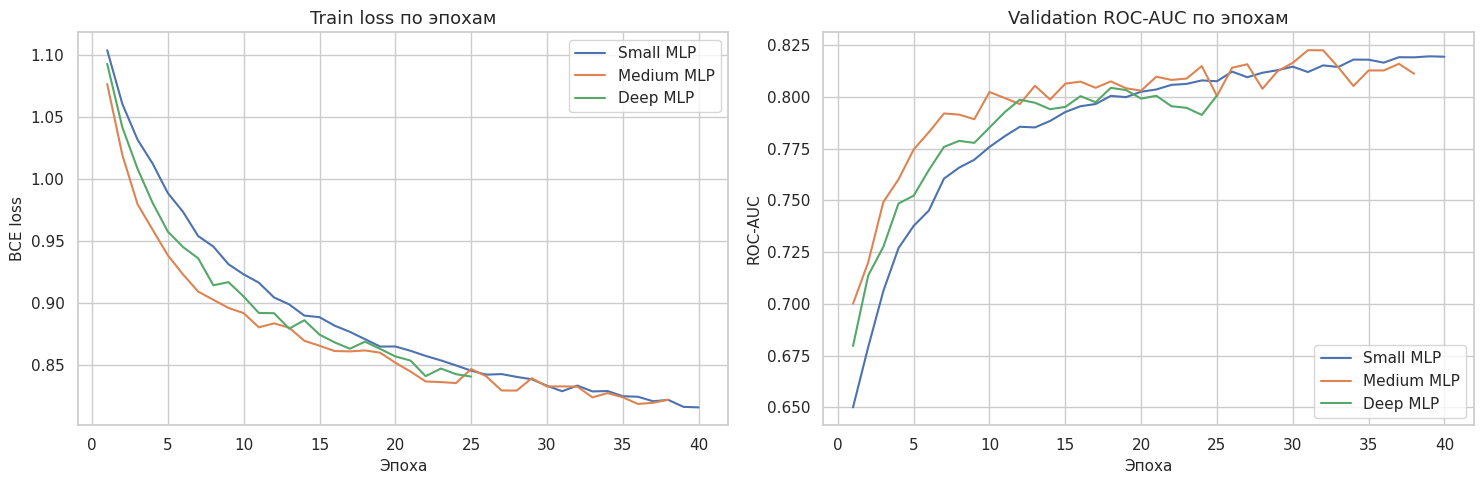

In [ ]:
# Линии обучения PyTorch-моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, hist in torch_histories.items():
    axes[0].plot(hist["epoch"], hist["train_loss"], label=name)
    axes[1].plot(hist["epoch"], hist["val_roc_auc"], label=name)

axes[0].set_title("Train loss по эпохам")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].set_title("Validation ROC-AUC по эпохам")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Автоматический подбор гиперпараметров PyTorch-модели

Подбираем не менее трех гиперпараметров:

- структура скрытых слоев `hidden_layers`;
- `dropout`;
- скорость обучения `lr`;
- L2-регуляризация `weight_decay`;
- размер батча `batch_size`.

Для экономии времени можно ограничить число конфигураций через `MAX_TUNING_RUNS`.

In [ ]:
param_grid = {
    "hidden_layers": [(64,), (128, 64), (256, 128, 64)],
    "dropout": [0.10, 0.25, 0.40],
    "lr": [1e-3, 7e-4],
    "weight_decay": [0.0, 1e-4, 3e-4],
    "batch_size": [128, 256],
    "use_batchnorm": [True],
}

all_configs = list(ParameterGrid(param_grid))
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(all_configs)

MAX_TUNING_RUNS = 8  # при наличии времени можно увеличить
selected_configs = all_configs[:MAX_TUNING_RUNS]

print("Всего возможных конфигураций:", len(all_configs))
print("Будет проверено конфигураций:", len(selected_configs))

tuning_rows = []
best_tuned_model = None
best_tuned_config = None
best_tuned_auc = -np.inf
best_tuned_history = None

for i, config in enumerate(selected_configs, start=1):
    print(f"\nGrid Search {i}/{len(selected_configs)}: {config}")
    torch.manual_seed(RANDOM_STATE + i)

    start = time.time()
    model, history, best_epoch = train_torch_model(
        config,
        X_train_np,
        y_train_np,
        X_val_np,
        y_val_np,
        epochs=35,
        patience=6,
        verbose=False,
    )
    fit_time = time.time() - start

    val_proba = predict_torch(model, X_val_np)
    val_threshold, val_f1_best = find_best_threshold(y_val_np, val_proba, metric="f1")
    val_metrics = evaluate_binary_classifier(y_val_np, val_proba, threshold=val_threshold)

    row = {
        "run": i,
        "hidden_layers": str(config["hidden_layers"]),
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "best_epoch": best_epoch,
        "fit_time_sec": fit_time,
        "val_f1": val_metrics["f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "threshold": val_threshold,
    }
    tuning_rows.append(row)

    if val_metrics["roc_auc"] > best_tuned_auc:
        best_tuned_auc = val_metrics["roc_auc"]
        best_tuned_model = model
        best_tuned_config = config
        best_tuned_history = history

tuning_results_df = pd.DataFrame(tuning_rows).sort_values("val_roc_auc", ascending=False)
display(tuning_results_df.head(10))
print("Лучшая конфигурация:", best_tuned_config)

Всего возможных конфигураций: 108
Будет проверено конфигураций: 8

Grid Search 1/8: {'batch_size': 128, 'dropout': 0.25, 'hidden_layers': (256, 128, 64), 'lr': 0.0007, 'use_batchnorm': True, 'weight_decay': 0.0}

Grid Search 2/8: {'batch_size': 128, 'dropout': 0.25, 'hidden_layers': (64,), 'lr': 0.001, 'use_batchnorm': True, 'weight_decay': 0.0}

Grid Search 3/8: {'batch_size': 256, 'dropout': 0.25, 'hidden_layers': (64,), 'lr': 0.0007, 'use_batchnorm': True, 'weight_decay': 0.0}

Grid Search 4/8: {'batch_size': 128, 'dropout': 0.25, 'hidden_layers': (128, 64), 'lr': 0.0007, 'use_batchnorm': True, 'weight_decay': 0.0001}

Grid Search 5/8: {'batch_size': 256, 'dropout': 0.1, 'hidden_layers': (64,), 'lr': 0.001, 'use_batchnorm': True, 'weight_decay': 0.0003}

Grid Search 6/8: {'batch_size': 128, 'dropout': 0.1, 'hidden_layers': (64,), 'lr': 0.001, 'use_batchnorm': True, 'weight_decay': 0.0}

Grid Search 7/8: {'batch_size': 128, 'dropout': 0.25, 'hidden_layers': (128, 64), 'lr': 0.001, 'u

,run,hidden_layers,dropout,lr,weight_decay,batch_size,best_epoch,fit_time_sec,val_f1,val_roc_auc,val_pr_auc,threshold
3,4,"(128, 64)",0.25,0.0007,0.0001,128,30,63.271561,0.573470,0.818911,0.574808,0.56
6,7,"(128, 64)",0.25,0.0010,0.0000,128,19,43.503037,0.572460,0.817903,0.571576,0.61
0,1,"(256, 128, 64)",0.25,0.0007,0.0000,128,18,52.504487,0.562442,0.807879,0.551256,0.51
4,5,"(64,)",0.10,0.0010,0.0003,256,33,58.565683,0.561131,0.804299,0.549306,0.58
2,3,"(64,)",0.25,0.0007,0.0000,256,29,53.882268,0.554856,0.800133,0.541135,0.55
7,8,"(256, 128, 64)",0.10,0.0007,0.0003,256,18,46.616695,0.557503,0.799933,0.553144,0.51
1,2,"(64,)",0.25,0.0010,0.0000,128,16,35.858433,0.548681,0.795201,0.533598,0.55
5,6,"(64,)",0.10,0.0010,0.0000,128,11,26.776354,0.532706,0.788462,0.507617,0.48


Лучшая конфигурация: {'batch_size': 128, 'dropout': 0.25, 'hidden_layers': (128, 64), 'lr': 0.0007, 'use_batchnorm': True, 'weight_decay': 0.0001}


,model,type,fit_time_sec,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,threshold
0,Tuned PyTorch MLP,pytorch_mlp_tuned,NaN,0.847455,0.580034,0.640684,0.608853,0.837135,0.61434,0.56



Лучшая настроенная PyTorch-модель на test
Порог: 0.5599999999999999
              precision    recall  f1-score   support

         0.0     0.9163    0.8945    0.9053      4625
         1.0     0.5800    0.6407    0.6089      1052

    accuracy                         0.8475      5677
   macro avg     0.7482    0.7676    0.7571      5677
weighted avg     0.8540    0.8475    0.8503      5677



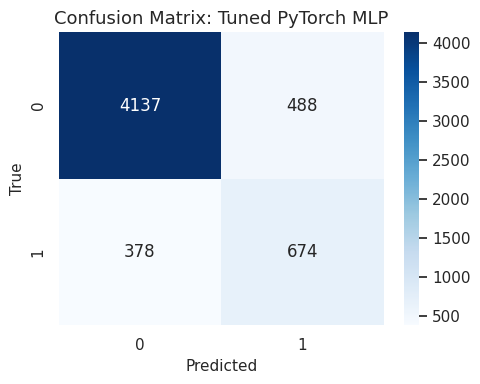

In [ ]:
# Финальная оценка лучшей настроенной PyTorch-модели
best_val_proba = predict_torch(best_tuned_model, X_val_np)
best_threshold, _ = find_best_threshold(y_val_np, best_val_proba, metric="f1")
best_test_proba = predict_torch(best_tuned_model, X_test_np)
best_tuned_metrics = evaluate_binary_classifier(y_test_np, best_test_proba, threshold=best_threshold)

best_tuned_row = {
    "model": "Tuned PyTorch MLP",
    "type": "pytorch_mlp_tuned",
    "fit_time_sec": np.nan,
    "test_accuracy": best_tuned_metrics["accuracy"],
    "test_precision": best_tuned_metrics["precision"],
    "test_recall": best_tuned_metrics["recall"],
    "test_f1": best_tuned_metrics["f1"],
    "test_roc_auc": best_tuned_metrics["roc_auc"],
    "test_pr_auc": best_tuned_metrics["pr_auc"],
    "threshold": best_threshold,
}

display(pd.DataFrame([best_tuned_row]))
cm_tuned = print_classification_summary(
    "Лучшая настроенная PyTorch-модель на test",
    y_test_np,
    best_test_proba,
    threshold=best_threshold,
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Tuned PyTorch MLP")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 15. Итоговое сравнение моделей

Сравним классические модели, три базовые MLP-архитектуры и лучшую настроенную PyTorch-модель.

,model,type,fit_time_sec,val_f1,val_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,threshold
0,Random Forest,classic_ml,34.603529,0.607917,0.838426,0.855205,0.613636,0.590304,0.601744,0.854337,0.632628,0.31
1,Gradient Boosting,classic_ml,26.486353,0.614804,0.843667,0.858552,0.621939,0.603612,0.612639,0.852831,0.644948,0.31
2,Tuned PyTorch MLP,pytorch_mlp_tuned,NaN,NaN,NaN,0.847455,0.580034,0.640684,0.608853,0.837135,0.614340,0.56
3,Small MLP,pytorch_mlp,67.601778,NaN,NaN,0.840585,0.559708,0.654943,0.603592,0.835295,0.608779,0.56
4,Medium MLP,pytorch_mlp,64.756619,NaN,NaN,0.836886,0.550400,0.653992,0.597741,0.835070,0.605516,0.47
5,Deep MLP,pytorch_mlp,50.212764,NaN,NaN,0.838647,0.558722,0.615019,0.585520,0.824310,0.584009,0.51
6,Logistic Regression,classic_ml,0.537682,0.467794,0.731963,0.785802,0.440751,0.579848,0.500821,0.760177,0.466342,0.53


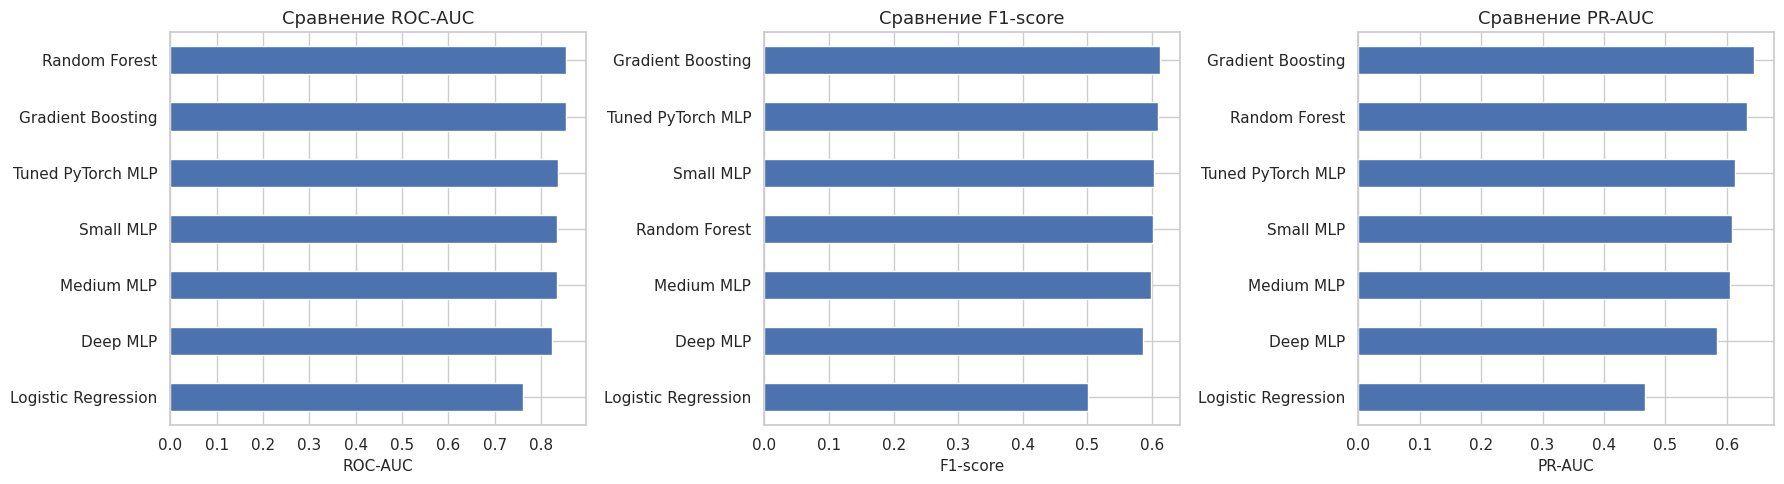

In [ ]:
all_results_df = pd.concat(
    [
        classic_results_df,
        torch_results_df.drop(columns=["architecture", "dropout", "lr", "weight_decay", "batch_size", "best_epoch"], errors="ignore"),
        pd.DataFrame([best_tuned_row]),
    ],
    ignore_index=True,
    sort=False,
)

all_results_df = all_results_df.sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
display(all_results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_results_df.sort_values("test_roc_auc").plot.barh(
    x="model", y="test_roc_auc", ax=axes[0], legend=False
)
axes[0].set_title("Сравнение ROC-AUC")
axes[0].set_xlabel("ROC-AUC")
axes[0].set_ylabel("")

all_results_df.sort_values("test_f1").plot.barh(
    x="model", y="test_f1", ax=axes[1], legend=False
)
axes[1].set_title("Сравнение F1-score")
axes[1].set_xlabel("F1-score")
axes[1].set_ylabel("")

all_results_df.sort_values("test_pr_auc").plot.barh(
    x="model", y="test_pr_auc", ax=axes[2], legend=False
)
axes[2].set_title("Сравнение PR-AUC")
axes[2].set_xlabel("PR-AUC")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

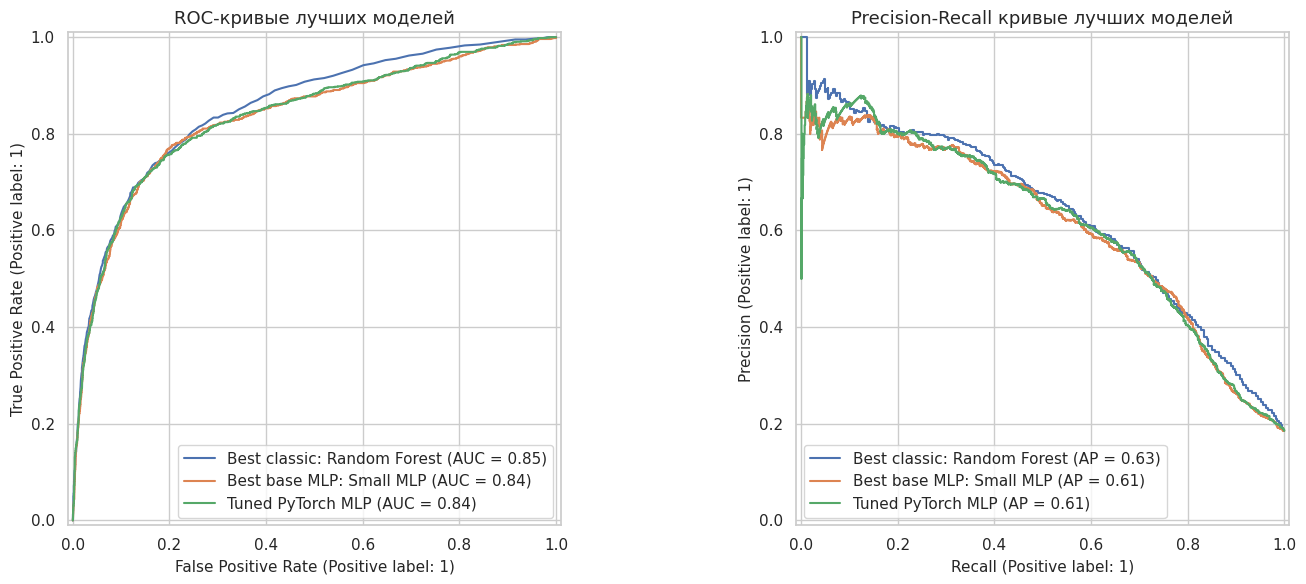

In [ ]:
# ROC и PR-кривые для лучших моделей каждого типа.
best_classic_name = classic_results_df.iloc[0]["model"]
best_torch_name = torch_results_df.iloc[0]["model"]
best_torch_proba = predict_torch(torch_models[best_torch_name], X_test_np)

curves = {
    f"Best classic: {best_classic_name}": classic_test_proba[best_classic_name],
    f"Best base MLP: {best_torch_name}": best_torch_proba,
    "Tuned PyTorch MLP": best_test_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, proba in curves.items():
    RocCurveDisplay.from_predictions(y_test_np, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test_np, proba, name=name, ax=axes[1])

axes[0].set_title("ROC-кривые лучших моделей")
axes[1].set_title("Precision-Recall кривые лучших моделей")
plt.tight_layout()
plt.show()

## 16. Проверка вклада графовых признаков

Чтобы понять, помог ли сетевой анализ, проведем небольшой ablation experiment:

- модель без графовых признаков;
- модель с графовыми признаками.

Для честности используем те же индексы разбиения train/validation/test.

,variant,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Без графовых признаков,0.53,0.807645,0.482906,0.537072,0.508551,0.765817,0.467503
1,С графовыми признаками,0.53,0.785802,0.440751,0.579848,0.500821,0.760177,0.466342


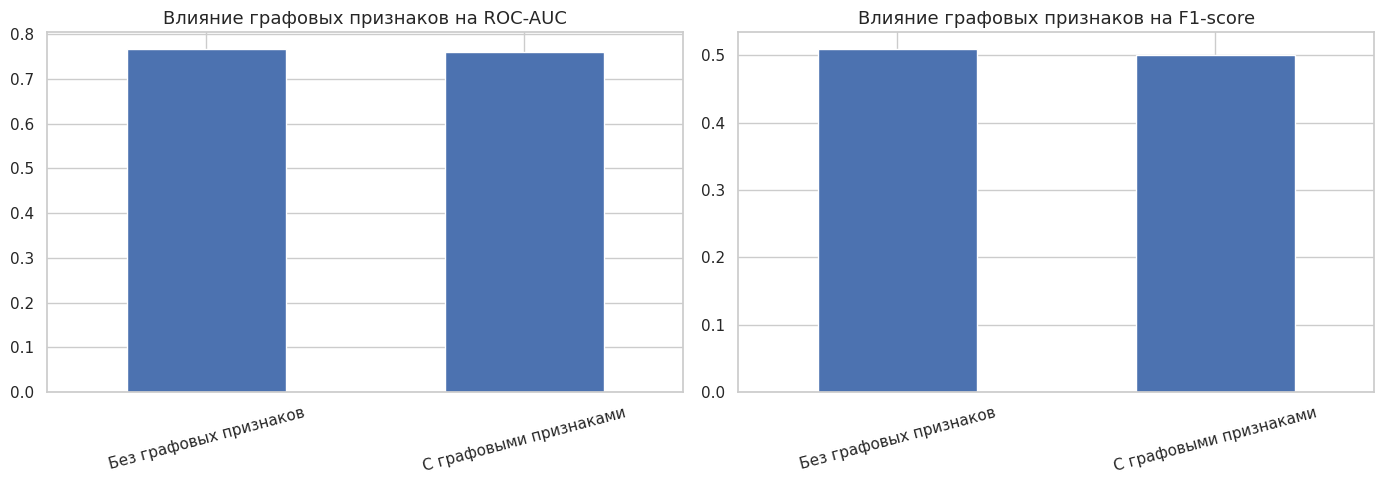

In [ ]:
graph_cols = [col for col in X_enriched.columns if col.startswith("graph_")]
X_without_graph = X_enriched.drop(columns=graph_cols)

X_train_no_graph = X_without_graph.iloc[idx_train].copy()
X_val_no_graph = X_without_graph.iloc[idx_val].copy()
X_test_no_graph = X_without_graph.iloc[idx_test].copy()

preprocessor_no_graph = build_tabular_preprocessor(X_train_no_graph)
X_train_ng = preprocessor_no_graph.fit_transform(X_train_no_graph)
X_val_ng = preprocessor_no_graph.transform(X_val_no_graph)
X_test_ng = preprocessor_no_graph.transform(X_test_no_graph)

if sp.issparse(X_train_ng):
    X_train_ng = X_train_ng.toarray()
    X_val_ng = X_val_ng.toarray()
    X_test_ng = X_test_ng.toarray()

X_train_ng = X_train_ng.astype(np.float32)
X_val_ng = X_val_ng.astype(np.float32)
X_test_ng = X_test_ng.astype(np.float32)

ablation_model_no_graph = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
ablation_model_with_graph = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)

ablation_model_no_graph.fit(X_train_ng, y_train_np)
ablation_model_with_graph.fit(X_train_np, y_train_np)

proba_ng_val = ablation_model_no_graph.predict_proba(X_val_ng)[:, 1]
proba_ng_test = ablation_model_no_graph.predict_proba(X_test_ng)[:, 1]
threshold_ng, _ = find_best_threshold(y_val_np, proba_ng_val, metric="f1")

proba_g_val = ablation_model_with_graph.predict_proba(X_val_np)[:, 1]
proba_g_test = ablation_model_with_graph.predict_proba(X_test_np)[:, 1]
threshold_g, _ = find_best_threshold(y_val_np, proba_g_val, metric="f1")

ablation_df = pd.DataFrame([
    {
        "variant": "Без графовых признаков",
        **evaluate_binary_classifier(y_test_np, proba_ng_test, threshold=threshold_ng),
    },
    {
        "variant": "С графовыми признаками",
        **evaluate_binary_classifier(y_test_np, proba_g_test, threshold=threshold_g),
    },
])

display(ablation_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ablation_df.plot.bar(x="variant", y="roc_auc", ax=axes[0], legend=False)
axes[0].set_title("Влияние графовых признаков на ROC-AUC")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_xlabel("")

ablation_df.plot.bar(x="variant", y="f1", ax=axes[1], legend=False)
axes[1].set_title("Влияние графовых признаков на F1-score")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## 17. Важность признаков

Для интерпретации используем Random Forest, потому что он умеет оценивать важность признаков. Особенно важно посмотреть, попали ли графовые признаки в число значимых.

,importance
balance_ratio,0.117736
balance_diff,0.096682
current_balance,0.080446
current_month_balance,0.044980
balance_stability_ratio,0.038642
current_month_debit,0.038248
previous_month_debit,0.033776
activity_ratio,0.033437
previous_month_end_balance,0.033031
debit_diff,0.032666


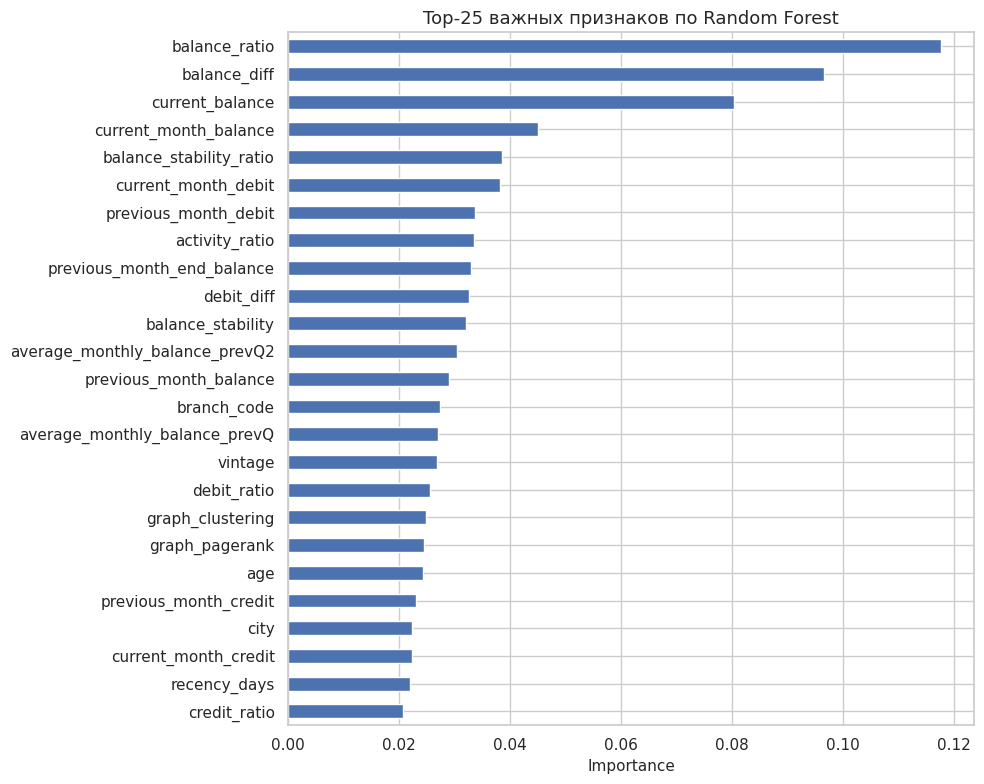

In [ ]:
# Важность признаков для Random Forest
rf_model = classic_models["Random Forest"]

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_train_np.shape[1])]

if hasattr(rf_model, "feature_importances_"):
    importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    top_importances = importances.head(25)

    display(top_importances.to_frame("importance"))

    plt.figure(figsize=(10, 8))
    top_importances.sort_values().plot(kind="barh")
    plt.title("Top-25 важных признаков по Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("У выбранной модели нет feature_importances_.")

## 18. Итоговые выводы

После запуска всех ячеек нужно ориентироваться на таблицу итогового сравнения моделей.

Типовая интерпретация результатов:

1. Если `ROC-AUC` высокий, модель хорошо ранжирует клиентов по вероятности оттока.
2. Если `Recall` высокий, модель находит большую часть клиентов, которые действительно уйдут. Это важно для банковского удержания клиентов.
3. Если `Precision` низкий, модель часто ошибочно относит лояльных клиентов к группе риска. Это может приводить к лишним маркетинговым затратам.
4. `F1-score` нужен как компромисс между Precision и Recall.
5. Если вариант с графовыми признаками лучше варианта без них, значит сетевое положение клиента среди похожих клиентов действительно несет дополнительную информацию.
6. Если PyTorch-модель не превосходит Random Forest/Gradient Boosting, это нормально для табличных данных: ансамбли деревьев часто являются очень сильным baseline. Важнее, что в работе реализована нейросетевая модель, несколько архитектур и подбор гиперпараметров.

**Содержательный вывод:**  
Для задачи прогнозирования оттока клиентов банка полезно объединять классические финансовые признаки, признаки клиентской активности и сетевые признаки, полученные из графа похожести клиентов. Такой подход позволяет учитывать не только индивидуальное поведение клиента, но и его положение среди похожих клиентов.

In [ ]:
# Автоматический краткий вывод по фактическим результатам после запуска.
best_row = all_results_df.iloc[0]

summary_text = f"""

Лучшая модель по ROC-AUC на тестовой выборке: **{best_row['model']}**.

- ROC-AUC: **{best_row['test_roc_auc']:.4f}**
- PR-AUC: **{best_row['test_pr_auc']:.4f}**
- F1-score: **{best_row['test_f1']:.4f}**
- Precision: **{best_row['test_precision']:.4f}**
- Recall: **{best_row['test_recall']:.4f}**

"""

display(Markdown(summary_text))



Лучшая модель по ROC-AUC на тестовой выборке: **Random Forest**.

- ROC-AUC: **0.8543**
- PR-AUC: **0.6326**
- F1-score: **0.6017**
- Precision: **0.6136**
- Recall: **0.5903**



## 19. Список использованных источников
1. Кочкаров А.А., Макрушин С.В., Каменчук В.Е., Блохин Н.В. Экспериментальная теория графов и алгоритмы анализа сетевых моделей

2. Методические указания по выполнению курсовых работ по дисциплине «Машинное обучение в семантическом и сетевом анализе».

3. Документация scikit-learn: метрики классификации, preprocessing, train/test split, модели машинного обучения.

4. Документация PyTorch: `BCEWithLogitsLoss`, `AdamW`, `DataLoader`, модули `torch.nn`.

5. Документация NetworkX: построение графов, центральности, PageRank, кластеризация, сообщества.

6. Géron A. Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.
